In [1]:
import pandas as pd
import scripts.db as db
import matplotlib.pyplot as plt

# Data Ingestion


---


In [2]:
#database engine connection
engine = db.db_engine()

In [3]:
#dataframe create
df = pd.read_sql("SELECT * FROM gold.total_news", engine)

In [4]:
df.head(5)

,title,article_text,author,published_date,source_type,is_fake
0,over million americans roll up sleeves for om...,health experts said it is too early to predict...,carla k johnson ap,2022-09-23,real_news,0
1,american airlines flyer charged banned for lif...,he was subdued by passengers and crew when he ...,mary papenfuss,2022-09-23,real_news,0
2,of the funniest tweets about cats and dogs thi...,until you have a dog you dont understand what ...,elyse wanshel,2022-09-23,real_news,0
3,the funniest tweets from parents this week sept,accidentally put grownup toothpaste on my todd...,caroline bologna,2022-09-23,real_news,0
4,woman who called cops on black birdwatcher los...,amy cooper accused investment firm franklin te...,nina golgowski,2022-09-22,real_news,0


---


# Preprocessing


### Preprocessing - Balance Dataset


In [5]:
df_copy = df.copy()

is_fake
0    189512
1     12815
Name: count, dtype: int64


[]

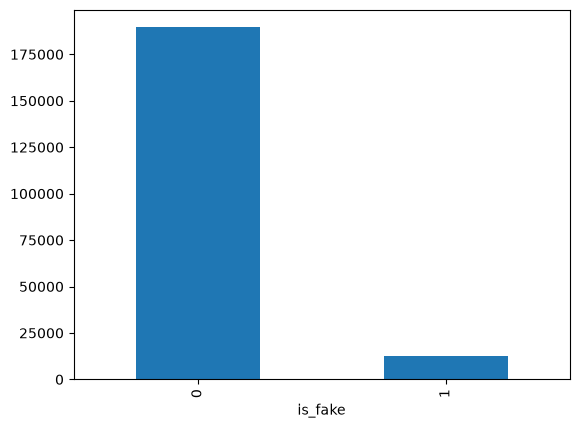

In [6]:
df_copy['is_fake'].value_counts().plot(kind='bar')
print(df_copy['is_fake'].value_counts())
plt.plot()

In [7]:
min = df_copy['is_fake'].value_counts().min()
df_balanced = df.groupby('is_fake').sample(n=min, random_state=42)

is_fake
0    12815
1    12815
Name: count, dtype: int64


[]

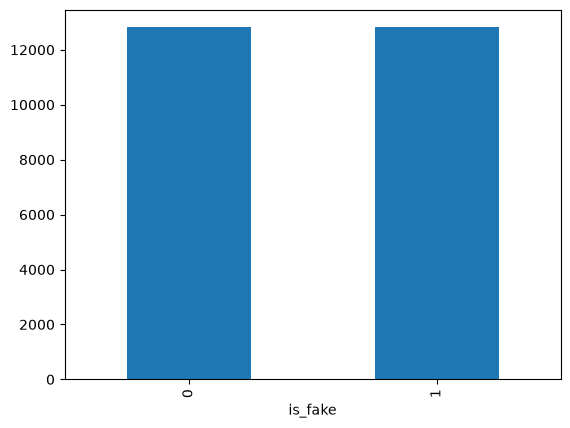

In [8]:
print(df_balanced['is_fake'].value_counts())
df_balanced['is_fake'].value_counts().plot(kind='bar')
plt.plot()

### Preprocessing - Removing Stopwords


In [9]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [10]:
nltk.download('stopwords')
nltk.download('punkt')

def stopword_remover(record):
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(record)
    filtered_text = [word for word in tokens if word not in stop_words]
    return filtered_text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [11]:
df_balanced['article_text_no_stopwords'] = df['article_text']\
    .apply(stopword_remover)\
        .apply(lambda text_list: " ".join(text_list))

# Mining


### Classification


In [12]:
from sentence_transformers import SentenceTransformer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [13]:
print("Loading Bert Model:")
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading Bert Model:


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [14]:
# 2. Extract features (X) and target labels (y)
# Replace 'processed_text' with the actual name of your column containing the joined strings
text_data = df_balanced['article_text_no_stopwords'].tolist() 
y = df_balanced['is_fake'].values

In [15]:
# 3. Generate Dense Embeddings
print(f"Generating embeddings for {len(text_data)} articles. This may take a moment...")
X_embeddings = model.encode(text_data, show_progress_bar=True)

Generating embeddings for 25630 articles. This may take a moment...


Batches:   0%|          | 0/801 [00:00<?, ?it/s]

In [16]:
y = df_balanced['is_fake'].values

In [17]:
# 4. Stratified Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [18]:
# 5. Train Linear Support Vector Classifier
print("Training Linear SVM...")
svm_model = LinearSVC(random_state=42, dual=False)
svm_model.fit(X_train, y_train)

Training Linear SVM...


,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adju

In [19]:
# 6. Model Evaluation
y_pred = svm_model.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Real News (0)', 'Fake News (1)']))


--- Classification Report ---
               precision    recall  f1-score   support

Real News (0)       0.93      0.98      0.95      2563
Fake News (1)       0.98      0.93      0.95      2563

     accuracy                           0.95      5126
    macro avg       0.96      0.95      0.95      5126
 weighted avg       0.96      0.95      0.95      5126

